# Section A: Output Prediction 

## A1.  K-Means by hand   

**First Prediction**

(A) 
Prediction 
[0 0 0 1 1 1]
I think K-Means will divide the values into two groups. The values 1, 2 and 3 are close to each other, while 10, 11 and 12 are also close to each other. So I expect the first three values to be in one cluster and the last three values to be in another cluster. Since the first initial centre is 1 and the second centre is 2, I expect the labels to be 0 for the first group and 1 for the second group.

(B)[ 2. 11.]After the points are divided into two groups, I think K-Means will calculate the average of the values in each group. The first group contains 1, 2 and 3, so its centre should be 2. The second group contains 10, 11 and 12, so its centre should be 11. Therefore, I predict the final centres will be 2 and 11.

(C)2.0 I think the inertia will be around 2, because after clustering, the points are quite close to their cluster centres. I calculated it approximately by looking at the distances from the points to their centres, but I am not completely sure whether K-Means uses the normal distance or squared distance for inertia.

(D)At the beginning, the centres are 1 and 2. I think the first cluster will contain 1 and 2, while the second cluster will contain 3, 10, 11 and 12.

For the first update, I calculate the centres as:

First centre = (1 + 2) / 2 = 1.5
Second centre = (3 + 10 + 11 + 12) / 4 = 9

So I predict the first updated centres will be 1.5 and 9.

For the second iteration, I think the groups will become 1, 2, 3 and 10, 11, 12, giving centres 2 and 11.

In [1]:
import numpy as np
from sklearn.cluster import KMeans
 
X = np.array([[1], [2], [3], [10], [11], [12]])
init = np.array([[1.0], [2.0]])        # deliberately poor starting centres
 
km = KMeans(n_clusters=2, init=init, n_init=1).fit(X)
 
print(km.labels_)              # line 1
print(km.cluster_centers_.ravel())   # line 2
print(km.inertia_)             # line 3


[0 0 0 1 1 1]
[ 2. 11.]
4.0


**Actual Output**

(A) [0 0 0 1 1 1]

(B) [ 2. 11.]

(C) **Prediction:**

I think the inertia will be **4** because the final cluster centres will be 2 and 11. The points are close to these centres, so the total squared distance should be small.

I calculate it like this:

* For 1: `(1 - 2)² = 1`
* For 2: `(2 - 2)² = 0`
* For 3: `(3 - 2)² = 1`
* For 10: `(10 - 11)² = 1`
* For 11: `(11 - 11)² = 0`
* For 12: `(12 - 11)² = 1`

So,

**Inertia = 1 + 0 + 1 + 1 + 0 + 1 = 4**

**Predicted inertia = 4.0**


(D) **Prediction:**

Initially, the two centres are **1 and 2**.

**First iteration:**

I think the points will be divided based on which centre they are closest to.

* Cluster 0 → `[1]`
* Cluster 1 → `[2, 3, 10, 11, 12]`

Then the centres are updated:

* Centre 0 = `1`
* Centre 1 = `(2 + 3 + 10 + 11 + 12) / 5 = 7.6`

So, after the first update, I predict the centres will be:

**`[1.0, 7.6]`**

**Second iteration:**

Using centres 1 and 7.6:

* Cluster 0 → `[1, 2, 3]`
* Cluster 1 → `[10, 11, 12]`

New centres:

* Centre 0 = `(1 + 2 + 3) / 3 = 2`
* Centre 1 = `(10 + 11 + 12) / 3 = 11`

So, after the second update, I predict the centres will be:

**`[2.0, 11.0]`**


## A2.  PCA on correlated data   

**First Prediction**

(A) [1.] I think line 1 will be 1.0 because the two columns are perfectly correlated. The second column is always two times the first column, so almost all the variation should be captured by the first principal component.

(B) [3.00 1.00 1.00 3.00] First, I think the mean of the first column is 2.5 and the mean of the second column is 5. After centering, the values will be around zero. I expect the PCA projection to give values close to [-3, -1, 1, 3]. Since the code uses np.abs(), I predict the final values will be approximately [3.00, 1.00, 1.00, 3.00]

(c) (4, 1) True I think line 3 will be (4, 1) because there are 4 rows in the original data and PCA was asked to keep only 1 component.

I also think line 4 will be True because the two original columns are perfectly correlated. One principal component should be enough to represent the original data without losing information.

(D) I think np.abs() is used just to make all the PCA values positive because negative values might be difficult to understand. Without np.abs(), I think the reviewer might think that the PCA calculation is wrong because some projected values are negative.

In [2]:
import numpy as np
from sklearn.decomposition import PCA
 
X = np.array([[1, 2], [2, 4], [3, 6], [4, 8]], dtype=float)
 
pca = PCA(n_components=1).fit(X)
Z = pca.transform(X)
 
print(pca.explained_variance_ratio_)       # line 1
print(np.abs(Z).ravel().round(2))          # line 2
print(Z.shape)                             # line 3
print(np.allclose(pca.inverse_transform(Z), X))   # line 4


[1.]
[3.35 1.12 1.12 3.35]
(4, 1)
True


**Actual Output** 

(A) [1.]

(B) [3.35 1.12 1.12 3.35]

(C) (4, 1)
True

(D)

I think `np.abs()` is used because PCA values can be either positive or negative depending on the direction of the principal component. The sign does not really change the PCA result.

Without `np.abs()`, a reviewer might see negative values and think that the PCA calculation is wrong, even though negative values are completely possible in PCA.

So, `np.abs()` is used here to show only the positive magnitude of the PCA values and make the output easier to compare.


# Section B: Code Refactoring 



## B1.  Customer segmentation script   

### Refactored Code

In [3]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Load the dataset
df = pd.read_csv("cleaned_customer_churn")

# Features used for customer segmentation
features = ["Annual_Income", "Spending_Score", "Age"]

# Range of k values to test
k_range = range(2, 6)

# Select the required features
X = df[features]

# Scale the features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Calculate silhouette score for each k
silhouette_scores = {}

for k in k_range:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores[k] = score

# Select the k with the highest silhouette score
best_k = max(silhouette_scores, key=silhouette_scores.get)

# Train the final K-Means model
km = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df["cluster"] = km.fit_predict(X_scaled)

# Create the cluster profile in a single step
cluster_profile = df.groupby("cluster")[features].mean()

# Display results
print("Silhouette Scores:")
print(silhouette_scores)

print("\nBest k:", best_k)

print("\nCluster Profile:")
print(cluster_profile)

Silhouette Scores:
{2: 0.22264798711362307, 3: 0.2351389134056244, 4: 0.25036229199441234, 5: 0.2581618703576263}

Best k: 5

Cluster Profile:
         Annual_Income  Spending_Score        Age
cluster                                          
0         50336.956522       39.065217  28.130435
1         89056.521739       44.978261  34.521739
2         70603.703704       27.259259  46.777778
3         60038.888889       79.944444  32.277778
4         54297.674419       54.581395  42.093023


### Change Log

- **Removed duplication:** Used a feature list and a loop to calculate the silhouette score for different values of k instead of writing separate code for k = 2, 3, 4 and 5.

- **Used StandardScaler:** Replaced the manual scaling calculations with scikit-learn's StandardScaler, making the preprocessing cleaner and easier to reuse.

- **Made the code reproducible:** Added `random_state=42` to K-Means so that the clustering results can be reproduced.

- **Made the feature list and k-range configurable:** The features are stored in `features` and the values of k are stored in `k_range`, so they can be changed easily.

- **Created the cluster profile in one step:** Used one `groupby()` statement with the feature list to calculate the average Annual Income, Spending Score and Age for each cluster.

## B2.  Dimensionality reduction helper   

In [4]:
import numpy as np
from sklearn.decomposition import PCA
 
def reduce(train, test):
    mu = test.mean(axis=0)
    sd = test.std(axis=0)
    train = (train - train.mean(axis=0)) / train.std(axis=0)
    test = (test - mu) / sd
    best = None
    for n in range(1, train.shape[1] + 1):
        p = PCA(n_components=n).fit(train)
        if sum(p.explained_variance_ratio_) >= 0.90:
            best = n
            break
    p = PCA(n_components=best).fit(train)
    return p.transform(train), p.transform(test)


(A) 

1. **Wrong scaling of test data:** The mean and standard deviation are calculated from the test data. The test data should not be used to decide the scaling values.

2. **Different scaling for train and test:** The training data is scaled using its own mean and standard deviation, while the test data is scaled using its own values. This can make the train and test data inconsistent.

3. **PCA is fitted many times:** The code fits PCA again and again inside the loop. This is unnecessary and makes the code less efficient.

4. **The 90% value is fixed:** The function always uses 90% variance and does not allow the user to change it.

5. **The function is not very reusable:** There are no clear parameters or explanation of what the function expects and returns.

(B)

In [5]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


def reduce(train, test, variance_target=0.90):
    
    # Scale using only the training data
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train)
    test_scaled = scaler.transform(test)

    # Fit PCA once with all components
    pca = PCA()
    pca.fit(train_scaled)

    # Calculate cumulative explained variance
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

    # Find the smallest number of components
    best = np.argmax(cumulative_variance >= variance_target) + 1

    # Transform train and test using the selected components
    train_reduced = pca.transform(train_scaled)[:, :best]
    test_reduced = pca.transform(test_scaled)[:, :best]

    return train_reduced, test_reduced

Why this code is better

**scaler.fit_transform(train)**

The scaler learns the mean and standard deviation only from the training data.


**scaler.transform(test)**

This avoids using information from the test set when preparing the training data.

(C) Docstring

In [6]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


def reduce(train, test, variance_target=0.90):
    """
    Scale the data using the training set and reduce it using PCA.

    The number of components is selected to keep the required
    amount of explained variance.
    """

    # Scale using only the training data
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train)
    test_scaled = scaler.transform(test)

    # Fit PCA once
    pca = PCA()
    pca.fit(train_scaled)

    # Calculate cumulative explained variance
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

    # Find the smallest number of components needed
    best = np.argmax(cumulative_variance >= variance_target) + 1

    # Transform the data
    train_reduced = pca.transform(train_scaled)[:, :best]
    test_reduced = pca.transform(test_scaled)[:, :best]

    return train_reduced, test_reduced

###  Change Log

- **Fixed the scaling:** Used `StandardScaler` and fitted it only on the training data so the test data does not affect the scaling.

- **Improved PCA efficiency:** PCA is fitted only once instead of fitting it repeatedly for every possible number of components.

- **Made the variance target configurable:** Added `variance_target=0.90`, so the user can change the required explained variance.

- **Made the function reusable:** Added a docstring and clear steps for scaling, selecting components, and transforming the train and test data.

# Section C: Scenario-Based Questions 

## C1.  Bank customer segmentation   

(A) **Preprocessing plan**

First, I will check the data for missing values, wrong values and duplicate records. For the credit-card spend, around 8% values are missing, so I can fill them using the median, because spending values can have some very high values.

The bank has some customers whose balance is 50–100 times higher than the median. These are extreme values. I will check these values carefully instead of directly deleting them, because they can be real high-value customers. If needed, I can use scaling or a suitable transformation so these customers do not dominate the clustering.

For numerical columns, I will use StandardScaler so that balance, transactions, products, tenure and spending are on similar scale.

The preferred channel is categorical data, so I will convert branch, mobile and web into numbers using one-hot encoding.

(B) **Deciding the number of segments**

Marketing asked for five segments, so I will first test k = 2 to 5, and also test nearby values like 6 if needed.

I will use silhouette score to check how well the customers are separated into groups. I can also use the elbow method to check how the clustering error changes for different k values.

But I will not select five only because Marketing asked for it. I will also check whether the segments are easy to understand and useful for marketing, like low-spending customers, high-value customers, frequent users etc.

If five gives good statistical results and useful customer groups, I will use five.

(C) **Checking stability and usefulness**

I will run the clustering multiple times with different random states and check whether similar customer groups are coming again.

I will also compare the size and main features of each segment. Finally, I will check with the marketing team whether the segments are meaningful and can actually be used for personalised offers.

## C2.  Clustering support-ticket embeddings   

(A) **Problems with the given plan**

1. t-SNE is mainly for visualization, so using its 2D output for K-Means can give misleading clusters.
2. The original embeddings have 768 dimensions, but reducing them directly to 2D can lose a lot of useful information.
3. K-Means on the 2D t-SNE output may create groups because of how t-SNE represents the data, not because the tickets actually have different topics.
4. There are 50,000 tickets, so running t-SNE on all the data can also be expensive and slow.
5. The clusters should not directly be called issue themes without checking what the tickets in each cluster are actually about.

(B) **Improved pipeline**

First, I will check the embeddings for missing or invalid values and make sure the data is properly prepared.

Then I can use PCA to reduce the 768 dimensions to a smaller number while keeping most of the useful information.

After PCA, I will use a clustering method such as K-Means on the reduced data. I can test different values of K and use measures like silhouette score to select a suitable number.

I will use t-SNE or UMAP mainly for visualization, not as the input for the final K-Means clustering. This will help me see whether the clusters look separated in 2D.

(C) **Validating the clusters**

I will check the silhouette score and compare the results for different K values. I will also read some sample tickets from each cluster and check whether they have a common issue or topic.

I can ask support-team members to review the clusters and confirm whether the identified themes make business sense. If the clusters change a lot with different settings or do not have clear topics, they may be artefacts rather than useful themes.

# Section D: Edge Case Questions 

## D1.  Clustering under unusual conditions   

(A) **Duplicate points with too many clusters requested**  

My prediction:

There are only 2 different points in the dataset: (1,1) and (2,2), even though there are 4 rows because both points are duplicated.

We are asking KMeans for 3 clusters. I expect KMeans to give a warning because there are only 2 distinct points available for 3 clusters.

I think it may still run, but one cluster may have no unique point of its own. The clustering should mainly be around (1,1) and (2,2).

In [7]:
X = np.array([[1, 1], [1, 1], [2, 2], [2, 2]], dtype=float)
KMeans(n_clusters=3, n_init=10, random_state=0).fit(X)


c:\Users\nani8\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


**Actual Output**

ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.

[1 1 0 0]

[[2. 2.]
 [1. 1.]
 [2. 2.]]

0.0



**What happened?**

KMeans did not give an error. It completed, but gave a ConvergenceWarning.

There are only 2 distinct points:

(1,1)
(2,2)

But we requested:

n_clusters=3

So KMeans cannot create 3 meaningful different clusters. Two cluster centres become the same:

[2, 2]
[1, 1]
[2, 2]

The inertia is 0.0 because every data point is exactly at its cluster centre.


**How to detect it programmatically?**

In [8]:
unique_points = np.unique(X, axis=0)

print("Unique points:", len(unique_points))
print("Requested clusters:", 3)

if len(unique_points) < 3:
    print("Warning: Number of unique points is smaller than n_clusters.")

Unique points: 2
Requested clusters: 3


**Robust handling**

In [9]:
unique_points = np.unique(X, axis=0)

if len(unique_points) < 3:
    print("Cannot create 3 meaningful clusters.")
else:
    km = KMeans(n_clusters=3, n_init=10, random_state=0)
    km.fit(X)

Cannot create 3 meaningful clusters.


### (B) A zero-variance feature.  

My prediction:

The second column is constant:

5, 5, 5

So its standard deviation is 0.

For the manual z-score, we divide by 0, so I expect NaN values and a runtime warning.

For StandardScaler, I expect it to handle the constant column safely and convert it to 0.

Therefore:

Manual scaling → NaN + warning
StandardScaler → 0, no error
KMeans on manual data should fail because KMeans cannot use NaN values.
KMeans on StandardScaler output should work.

## Code

In [10]:
# X = np.array([[1, 5], [2, 5], [3, 5]], dtype=float)   # 2nd column is constant
# manual = (X - X.mean(axis=0)) / X.std(axis=0, ddof=1)
# sk     = StandardScaler().fit_transform(X)
# KMeans(n_clusters=2, n_init=10).fit(manual)   # and again with sk

ValueError                                Traceback (most recent call last)
Cell In[10], line 4
      1 X = np.array([[1, 5], [2, 5], [3, 5]], dtype=float)   # 2nd column is constant
      2 manual = (X - X.mean(axis=0)) / X.std(axis=0, ddof=1)
      3 sk     = StandardScaler().fit_transform(X)
----> 4 KMeans(n_clusters=2, n_init=10).fit(manual)   # and again with sk

File ~\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py:1336, in _fit_context.<locals>.decorator.<locals>.wrapper(estimator, *args, **kwargs)
   1329     estimator._validate_params()
   1331 with config_context(
   1332     skip_parameter_validation=(
   1333         prefer_skip_nested_validation or global_skip_validation
   1334     )
   1335 ):
-> 1336     return fit_method(estimator, *args, **kwargs)

File ~\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\cluster\_kmeans.py:1460, in KMeans.fit(self, X, y, sample_weight)
   1432 @_fit_context(prefer_skip_nested_validation=True)
   1433 def fit(self, X, y=None, sample_weight=None):
   1434     """Compute k-means clustering.
   1435 
   1436     Parameters
   (...)   1458         Fitted estimator.
   1459     """
...
    181     )
--> 182 raise ValueError(msg_err)

ValueError: Input X contains NaN.
KMeans does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

**Actual behaviour**

The manual calculation gives:

RuntimeWarning: invalid value encountered in divide

[[-1. nan]
 [ 0. nan]
 [ 1. nan]]

The reason is:

5 - 5 = 0
0 / 0 = NaN

So the second column becomes NaN.

When we run:

KMeans(n_clusters=2, n_init=10).fit(manual)

it gives a ValueError because KMeans does not accept NaN values.

Typical error:

ValueError: Input X contains NaN.
KMeans does not accept missing values encoded as NaN natively.

**StandardScaler result**

StandardScaler handles the zero-variance column:

[[-1.22474487  0.        ]
 [ 0.          0.        ]
 [ 1.22474487  0.        ]]

The second column becomes all 0.

KMeans then runs successfully:

Labels:
[0 0 1]

Inertia:
0.75

There is no warning from KMeans in this case.

**Why is there a difference?**

The manual formula divides by the standard deviation. Since the second feature has standard deviation 0, it causes division by zero.

StandardScaler handles this case safely. A feature with zero variance does not provide any useful information for clustering, so it is effectively converted to zero.

**Robust handling**

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled)

[[-1. -1.]
 [-1. -1.]
 [ 1.  1.]
 [ 1.  1.]]


In [12]:
std = X.std(axis=0)

print("Standard deviations:", std)

if np.any(std == 0):
    print("Warning: Zero-variance feature found.")

Standard deviations: [0.5 0.5]


### (C) Non-spherical clusters.  

My prediction:

The make_moons data has two curved moon-shaped clusters.

I expect KMeans to perform poorly because KMeans works better when clusters are roughly round/spherical.

I expect DBSCAN to perform better because it groups points based on density and can find curved-shaped clusters.

So I predict:

KMeans ARI → relatively low
DBSCAN ARI → close to 1

In [13]:
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import adjusted_rand_score
 
X, y_true = make_moons(n_samples=300, noise=0.05, random_state=0)
km_labels = KMeans(n_clusters=2, n_init=10, random_state=0).fit_predict(X)
db_labels = DBSCAN(eps=0.2).fit_predict(X)


**Actual output**

In [14]:
print("KMeans ARI:", adjusted_rand_score(y_true, km_labels))
print("DBSCAN ARI:", adjusted_rand_score(y_true, db_labels))

KMeans ARI: 0.24083922992439677
DBSCAN ARI: 1.0


**Why?**

KMeans:

KMeans assumes that clusters are roughly round/spherical and separates them using distance from cluster centres.

But the moon clusters are curved, so KMeans divides the data incorrectly.

Therefore, its ARI is only:

0.2408

DBSCAN:

DBSCAN does not depend on cluster centres. It looks at density and nearby points, so it can follow the curved moon shapes.

Therefore, it gets:

1.0

An ARI of 1.0 means the clustering matches the true labels perfectly.

### (D) Production checks

1. Silhouette score check — if the silhouette score is very low, flag the K-Means result because clusters may not be well separated.
2. Cluster size check — if one cluster has almost all the data and another has very few points, flag the result.
3. Run K-Means with different random states — if the cluster assignments change a lot, the result is not stable and should be flagged.


## D2.  Dimensionality reduction under unusual conditions   

### (A) More components requested than the data allows

My prediction:

The dataset has:

5 samples
20 features

We are asking PCA for:

n_components=10

I predict PCA will give an error, because we cannot get 10 components from only 5 samples when using the default PCA solver.

**Code**

In [15]:
# X = np.random.RandomState(0).rand(5, 20)      # 5 samples, 20 features
# PCA(n_components=10).fit(X)

**Actual behaviour**


ValueError                                Traceback (most recent call last)
Cell In[16], line 2
      1 X = np.random.RandomState(0).rand(5, 20)      # 5 samples, 20 features
----> 2 PCA(n_components=10).fit(X)

File ~\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py:1336, in _fit_context.<locals>.decorator.<locals>.wrapper(estimator, *args, **kwargs)
   1329     estimator._validate_params()
   1331 with config_context(
   1332     skip_parameter_validation=(
   1333         prefer_skip_nested_validation or global_skip_validation
   1334     )
   1335 ):
-> 1336     return fit_method(estimator, *args, **kwargs)

File ~\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\decomposition\_pca.py:440, in PCA.fit(self, X, y)
    422 @_fit_context(prefer_skip_nested_validation=True)
    423 def fit(self, X, y=None):
    424     """Fit the model with X.
    425 
    426     Parameters
   (...)    438         Returns the instance itself.
    439     """
--> 440     self._fit(X)
    441     return self
...
    563 # is a scipy sparse array.
    564 # TODO: remove the following two lines when scikit-learn only depends
    565 # on scipy versions that no longer support scipy.sparse matrices.

ValueError: n_components=10 must be between 0 and min(n_samples, n_features)=5 with svd_solver='full'
Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...

**Why?**

For PCA, the maximum number of components is:

min(number of samples, number of features)

Here:

min(5, 20) = 5

Therefore, the maximum is 5 components.

So:

PCA(n_components=5)

is valid, but:

PCA(n_components=10)

is not valid with the default solver.

Rule

Maximum PCA components = min(n_samples, n_features)

For this data:

min(5, 20) = 5

**robust check**

In [16]:
max_components = min(X.shape[0], X.shape[1])

if 10 > max_components:
    print("Requested components are too many.")

Requested components are too many.


### (B) Missing values

My prediction:

The data contains one NaN value:

X[0, 0] = np.nan

I expect PCA will give an error, because PCA cannot directly work with missing (NaN) values.

**Code**

In [17]:
# X = np.random.RandomState(0).rand(10, 3)
# X[0, 0] = np.nan
# PCA(n_components=2).fit(X)


---------------------------------------------------------------------------
ValueError                                Traceback (most recent call last)
Cell In[19], line 3
      1 X = np.random.RandomState(0).rand(10, 3)
      2 X[0, 0] = np.nan
----> 3 PCA(n_components=2).fit(X)

File ~\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py:1336, in _fit_context.<locals>.decorator.<locals>.wrapper(estimator, *args, **kwargs)
   1329     estimator._validate_params()
   1331 with config_context(
   1332     skip_parameter_validation=(
   1333         prefer_skip_nested_validation or global_skip_validation
   1334     )
   1335 ):
-> 1336     return fit_method(estimator, *args, **kwargs)

File ~\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\decomposition\_pca.py:440, in PCA.fit(self, X, y)
    422 @_fit_context(prefer_skip_nested_validation=True)
    423 def fit(self, X, y=None):
    424     """Fit the model with X.
    425 
    426     Parameters
   (...)    438         Returns the instance itself.
    439     """
--> 440     self._fit(X)
...
    181     )
--> 182 raise ValueError(msg_err)

ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values
Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...

**Actual behaviour**

PCA(n_components=2).fit(X)

gives a ValueError similar to:

ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively.

So PCA does not run successfully.

**Fix without test-data leakage**

In [18]:
# from sklearn.impute import SimpleImputer
#from sklearn.decomposition import PCA

#imputer = SimpleImputer(strategy="median")

#X_train_imputed = imputer.fit_transform(X_train)
#X_test_imputed = imputer.transform(X_test)

#pca = PCA(n_components=2)

#X_train_pca = pca.fit_transform(X_train_imputed)
#X_test_pca = pca.transform(X_test_imputed)

---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
Cell In[25], line 6
      2 from sklearn.decomposition import PCA
      3 
      4 imputer = SimpleImputer(strategy="median")
      5 
----> 6 X_train_imputed = imputer.fit_transform(X_train)
      7 X_test_imputed = imputer.transform(X_test)
      8 
      9 pca = PCA(n_components=2)

NameError: name 'X_train' is not defined

**Why?**

fit_transform() is used only on training data. It learns the median from the training set.

For test data, we only use:

**imputer.transform(X_test)**

So the test data does not influence the median or PCA model.

### (C) Degenerate data

My prediction:

All values in the dataset are 1:

np.ones((6, 3))

So all three features have zero variance. There is no variation for PCA to find.

I expect the explained variance ratios to be:

[0. 0.]

In [19]:
PCA(n_components=2).fit(np.ones((6, 3))).explained_variance_ratio_

c:\Users\nani8\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\decomposition\_pca.py:646: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var


array([nan, nan])

**Actual output**

array([nan, nan])

**Why?**

PCA looks for directions where the data has variation.

Here every row is exactly:

[1, 1, 1]
[1, 1, 1]
[1, 1, 1]
...

So there is no variation at all.

Therefore:

Variance of every feature = 0
Total variance = 0
PCA cannot explain any variation
explained_variance_ratio_ becomes [0., 0.]

**How would I guard against it**

In [20]:
#if np.all(np.var(X, axis=0) == 0):
#   print("Warning: Data has zero variance. PCA should not be applied.")
#else:
#    pca = PCA(n_components=2)
#    pca.fit(X)


---------------------------------------------------------------------------
ValueError                                Traceback (most recent call last)
Cell In[28], line 5
      1 if np.all(np.var(X, axis=0) == 0):
      2     print("Warning: Data has zero variance. PCA should not be applied.")
      3 else:
      4     pca = PCA(n_components=2)
----> 5     pca.fit(X)

File ~\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py:1336, in _fit_context.<locals>.decorator.<locals>.wrapper(estimator, *args, **kwargs)
   1329     estimator._validate_params()
   1331 with config_context(
   1332     skip_parameter_validation=(
   1333         prefer_skip_nested_validation or global_skip_validation
   1334     )
   1335 ):
-> 1336     return fit_method(estimator, *args, **kwargs)

File ~\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\decomposition\_pca.py:440, in PCA.fit(self, X, y)
    422 @_fit_context(prefer_skip_nested_validation=True)
    423 def fit(self, X, y=None):
    424     """Fit the model with X.
    425 
    426     Parameters
   (...)    438         Returns the instance itself.
...
    181     )
--> 182 raise ValueError(msg_err)

ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values
Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...

In [21]:
variances = np.var(X, axis=0)

X = X[:, variances > 0]

### (D) Features on very different scales

My prediction:

Feature 2 has values around 1000 times larger than feature 1.

So, without standardisation, I expect PCA to give almost all the variance to feature 2.

After standardisation, both features will have similar scale, so I expect the variance to be much more balanced between the two principal components.

In [22]:
rng = np.random.RandomState(0)

A = np.c_[rng.normal(0, 1, 200),
          rng.normal(0, 1, 200) * 1000]

print(PCA().fit(A).explained_variance_ratio_)

print(
    PCA().fit(
        StandardScaler().fit_transform(A)
    ).explained_variance_ratio_
)

[9.99998834e-01 1.16589485e-06]
[0.53780576 0.46219424]


**Actual Ouput**

Without standardisation

[9.99998834e-01 1.16589485e-06]

Approximately:

[99.99988%, 0.00012%]

After standardisation

[0.53780576 0.46219424]

Approximately:

[53.78%, 46.22%]

**Why is there such a big difference?**

Without standardisation, feature 2 has a much larger numerical scale:

Feature 1 → around 1
Feature 2 → around 1000

PCA is based on variance. Because feature 2 is 1000 times larger, its variance is roughly 1,000,000 times larger.

So PCA thinks almost all the important variation is in feature 2:

PC1 ≈ 99.99988%
PC2 ≈ 0.00012%

After StandardScaler, both features are put on a similar scale. Therefore, PCA can consider both features more fairly:

PC1 ≈ 53.78%
PC2 ≈ 46.22%

**What does this tell us?**

We should standardise before PCA when features are measured in very different units or have very different scales.

Otherwise, PCA may mainly capture the feature with the largest numerical scale, rather than the feature that is actually more important.

# Section E: Design Challenge 

## E.  End-to-end customer segmentation pipeline   

### E1 — Problem Framing and Feature Design

### Business objective

The main objective is to divide customers into useful groups so that the company can give different retention and marketing offers to different types of customers.

I will use monthly_spend, orders_per_month, return_rate, tenure_months and preferred_channel.

I will drop customer_id because it is only an identifier and does not describe customer behaviour.

For missing monthly_spend values, I will use median imputation because some values are missing and median is less affected by extreme values.

The numerical features will be standardized because they have different units and scales.

preferred_channel is categorical, so I will use one-hot encoding.

I will use PCA after preprocessing to reduce the number of dimensions before K-Means clustering. PCA will keep 90% of the explained variance.

The dataset has some differences in customer spending, so keeping the original numerical features is useful for finding meaningful customer groups.

### E2 — Pipeline Implementation

In [23]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.metrics import adjusted_rand_score
import matplotlib.pyplot as plt

In [24]:
def make_customers(n=1500, seed=42):
    rng = np.random.default_rng(seed)

    seg = rng.choice(
        4,
        size=n,
        p=[0.40, 0.30, 0.20, 0.10]
    )

    spec = {
        0: (300, 6, 0.30),
        1: (900, 14, 0.10),
        2: (2500, 30, 0.05),
        3: (6000, 12, 0.02)
    }

    spend = np.array([
        max(5, rng.normal(spec[s][0], spec[s][0] * 0.25))
        for s in seg
    ])

    orders = np.array([
        max(1, rng.poisson(spec[s][1]))
        for s in seg
    ])

    ret = np.array([
        min(1, max(0, rng.normal(spec[s][2], 0.05)))
        for s in seg
    ])

    df = pd.DataFrame({
        "customer_id": np.arange(1, n + 1),
        "monthly_spend": spend.round(2),
        "orders_per_month": orders,
        "return_rate": ret.round(3),
        "tenure_months": rng.integers(1, 60, n),
        "preferred_channel": rng.choice(
            ["web", "app", "store"],
            n,
            p=[0.45, 0.40, 0.15]
        )
    })

    df.loc[
        rng.choice(n, 60, replace=False),
        "monthly_spend"
    ] = np.nan

    return df


df = make_customers()

print(df.head())
print("\nShape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

   customer_id  monthly_spend  orders_per_month  return_rate  tenure_months  \
0            1        3101.85                32        0.129             47   
1            2         736.96                17        0.121             26   
2            3        1966.40                26        0.031              4   
3            4        1003.43                15        0.107             22   
4            5         374.14                11        0.249              6   

  preferred_channel  
0               app  
1               app  
2             store  
3             store  
4               app  

Shape: (1500, 6)

Missing values:
customer_id           0
monthly_spend        60
orders_per_month      0
return_rate           0
tenure_months         0
preferred_channel     0
dtype: int64


In [25]:
features = [
    "monthly_spend",
    "orders_per_month",
    "return_rate",
    "tenure_months",
    "preferred_channel"
]

numeric_features = [
    "monthly_spend",
    "orders_per_month",
    "return_rate",
    "tenure_months"
]

categorical_features = [
    "preferred_channel"
]

X = df[features]

In [26]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        ),

        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        sparse_output=False
                    )
                )
            ]),
            categorical_features
        )
    ]
)

In [27]:
final_pipeline = Pipeline([
    ("preprocess", preprocessor),

    ("pca", PCA(
        n_components=0.90,
        random_state=42
    )),

    ("cluster", KMeans(
        n_clusters=4,
        n_init=20,
        random_state=42
    ))
])

final_pipeline.fit(X)

print("Pipeline completed successfully.")

Pipeline completed successfully.


### E3 — Model Selection and Validation

In [28]:
results = []

for k in range(2, 7):

    pipeline = Pipeline([
        ("preprocess", preprocessor),

        ("pca", PCA(
            n_components=0.90,
            random_state=42
        )),

        ("cluster", KMeans(
            n_clusters=k,
            n_init=20,
            random_state=42
        ))
    ])

    pipeline.fit(X)

    X_pca = pipeline.named_steps["pca"].transform(
        pipeline.named_steps["preprocess"].transform(X)
    )

    labels = pipeline.named_steps["cluster"].labels_

    silhouette = silhouette_score(X_pca, labels)

    calinski = calinski_harabasz_score(
        X_pca,
        labels
    )

    inertia = pipeline.named_steps["cluster"].inertia_

    results.append([
        k,
        silhouette,
        calinski,
        inertia
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "K",
        "Silhouette Score",
        "Calinski-Harabasz Score",
        "Inertia"
    ]
)

print(results_df.round(3))

   K  Silhouette Score  Calinski-Harabasz Score   Inertia
0  2             0.313                  816.831  4299.266
1  3             0.330                  709.949  3409.592
2  4             0.316                  722.271  2713.431
3  5             0.305                  735.229  2239.028
4  6             0.310                  746.734  1898.647


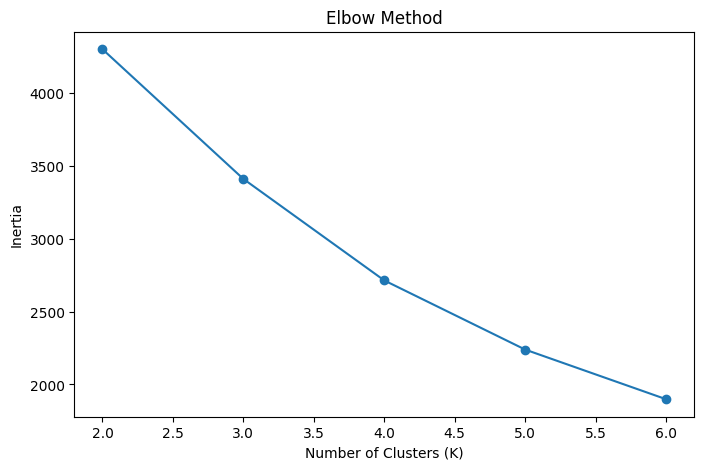

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["K"],
    results_df["Inertia"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [30]:
base_pipeline = Pipeline([
    ("preprocess", preprocessor),

    ("pca", PCA(
        n_components=0.90,
        random_state=42
    )),

    ("cluster", KMeans(
        n_clusters=4,
        n_init=20,
        random_state=42
    ))
])

base_pipeline.fit(X)

base_labels = base_pipeline.named_steps[
    "cluster"
].labels_

stability_results = []

for seed in [0, 1, 2, 3, 4]:

    test_pipeline = Pipeline([
        ("preprocess", preprocessor),

        ("pca", PCA(
            n_components=0.90,
            random_state=42
        )),

        ("cluster", KMeans(
            n_clusters=4,
            n_init=20,
            random_state=seed
        ))
    ])

    test_pipeline.fit(X)

    test_labels = test_pipeline.named_steps[
        "cluster"
    ].labels_

    ari = adjusted_rand_score(
        base_labels,
        test_labels
    )

    stability_results.append([
        seed,
        ari
    ])

stability_df = pd.DataFrame(
    stability_results,
    columns=["Random Seed", "ARI with Base Clustering"]
)

print(stability_df)

   Random Seed  ARI with Base Clustering
0            0                       1.0
1            1                       1.0
2            2                       1.0
3            3                       1.0
4            4                       1.0


### E3. Model Selection and Validation

I tested K values from 2 to 6 using silhouette score, Calinski-Harabasz score and the elbow method.

The silhouette score was highest for K=3 (0.330), while the Calinski-Harabasz score was highest for K=2. Therefore, the statistical measures do not give the same answer.

The elbow plot shows a strong reduction in inertia up to around K=4 and then the improvement becomes smaller. K=4 also gives four useful customer groups based mainly on spending and ordering behaviour.

I also tested K=4 using random seeds 0 to 4. The Adjusted Rand Index compared with the base clustering was 1.0 for all seeds, showing that the result is very stable.

Therefore, I selected K=4. This is not because four is automatically correct, but because it gives stable and more useful business segments while the statistical criteria are somewhat ambiguous.

### E4 — Segment Profiling and Action

In [31]:
final_pipeline = Pipeline([
    ("preprocess", preprocessor),

    ("pca", PCA(
        n_components=0.90,
        random_state=42
    )),

    ("cluster", KMeans(
        n_clusters=4,
        n_init=20,
        random_state=42
    ))
])

final_pipeline.fit(X)

df["segment"] = final_pipeline.predict(X)

print(df["segment"].value_counts().sort_index())

segment
0    288
1    599
2    476
3    137
Name: count, dtype: int64


In [32]:
profile = df.groupby("segment").agg(
    Size=("customer_id", "count"),
    Monthly_Spend=("monthly_spend", "mean"),
    Orders_Per_Month=("orders_per_month", "mean"),
    Return_Rate=("return_rate", "mean"),
    Tenure_Months=("tenure_months", "mean")
).round(2)

channel = df.groupby("segment")[
    "preferred_channel"
].agg(lambda x: x.mode().iloc[0])

profile["Preferred_Channel"] = channel

print(profile)

         Size  Monthly_Spend  Orders_Per_Month  Return_Rate  Tenure_Months  \
segment                                                                      
0         288        2529.28             30.09         0.06          31.02   
1         599         303.31              6.14         0.30          30.52   
2         476         958.80             13.73         0.09          27.50   
3         137        6042.04             11.66         0.03          33.09   

        Preferred_Channel  
segment                    
0                     web  
1                     web  
2                     web  
3                     web  


### E4. Segment Profiling and Action

The four clusters show clear differences in customer behaviour.

Segment 0 is a High-Value Frequent group because customers have high monthly spending and around 30 orders per month with a low return rate. I would give this group loyalty rewards and VIP benefits.

Segment 1 is a Low-Value High-Return group. These customers have low spending, fewer orders and the highest return rate. I would use personalised offers and try to reduce returns through better product recommendations.

Segment 2 is a Regular Loyal group with medium spending, regular orders and a low return rate. I would encourage repeat purchases using bundles and loyalty rewards.

Segment 3 is a Premium group with the highest monthly spending and low return rate. I would provide exclusive products, VIP discounts and priority customer support.

The preferred channel is categorical, so I report its most common value instead of calculating a mean.

### E5 — Productionisation and Extension 

After deployment, I would monitor the customer data regularly for changes in monthly spend, orders, return rate, tenure and preferred channel. I would also monitor missing values, cluster sizes and the distance of new customers from the cluster centres. If the feature distributions change strongly or cluster sizes become very different, I would investigate data drift. I would retrain the pipeline when drift becomes persistent or when the segments stop being useful for business decisions.

To include 384-dimensional product-review embeddings, I would add the embeddings as another input branch. Because 384 dimensions are large, I would reduce them using PCA before combining them with the customer features. I would also scale the embedding features so that they do not dominate the numerical customer features.

For visualization, I would use the first two PCA components in a 2-D scatter plot. This can show whether segments look separated visually, but it cannot prove that the segments are truly meaningful or explain customer behaviour by itself.

### 2-D Visualization required by E5

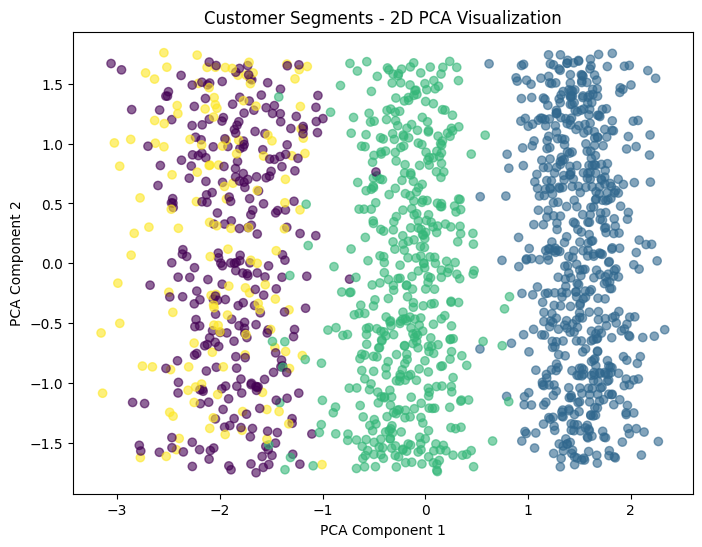

In [33]:
# Get the PCA representation from the fitted pipeline

X_processed = final_pipeline.named_steps[
    "preprocess"
].transform(X)

X_pca = final_pipeline.named_steps[
    "pca"
].transform(X_processed)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df["segment"],
    alpha=0.6
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Customer Segments - 2D PCA Visualization")

plt.show()

In [34]:
new_customer = pd.DataFrame({
    "monthly_spend": [3000],
    "orders_per_month": [20],
    "return_rate": [0.05],
    "tenure_months": [24],
    "preferred_channel": ["app"]
})

new_segment = final_pipeline.predict(new_customer)

print("New customer segment:", new_segment[0])

New customer segment: 0
